In [61]:
import os
import glob
from tqdm import tqdm
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.metrics import f1_score

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

import os
import zipfile
import shutil

def create_folder(path):
    """
    폴더를 생성합니다. 이미 폴더가 존재하면 아무 동작도 하지 않습니다.
    
    :param path: 생성할 폴더의 경로
    """
    if not os.path.exists(path):
        os.makedirs(path)

def extract_zip(zip_file_path, extract_to_path):
    """
    zip 파일을 지정된 경로로 압축 해제합니다.
    
    :param zip_file_path: 압축 해제할 zip 파일의 경로
    :param extract_to_path: 압축 해제된 파일을 저장할 경로
    """
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            for member in zip_ref.namelist():
                filename = os.path.basename(member)
                # 파일이 디렉토리가 아닌 경우에만 추출
                if not filename:
                    continue
                # 현재 디렉토리에 파일 추출
                source = zip_ref.open(member)
                target = open(os.path.join(extract_to_path, filename), "wb")
                with source, target:
                    shutil.copyfileobj(source, target)
        print(f"{zip_file_path} 압축 해제 완료!")
    except zipfile.BadZipFile:
        print(f"Error: {zip_file_path} is not a valid zip file")
    except FileNotFoundError:
        print(f"Error: {zip_file_path} not found")

def setup_folders_and_extract():
    # 폴더 생성
    base_folders = ['train', 'test']
    train_subfolders = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    for folder in base_folders:
        create_folder(folder)
    
    for subfolder in train_subfolders:
        create_folder(f'train/{subfolder}')
    
    # 압축 파일 목록과 해당하는 폴더 경로
    train_zip_files = ['airplane.zip', 'automobile.zip', 'bird.zip', 'cat.zip', 'deer.zip', 'dog.zip', 'frog.zip', 'horse.zip', 'ship.zip', 'truck.zip']
    train_extract_paths = [f'train/{subfolder}/' for subfolder in train_subfolders]
    
    # 압축 해제 (train 데이터셋)
    for zip_file, extract_path in zip(train_zip_files, train_extract_paths):
        extract_zip(zip_file, extract_path)
    
    # 추가된 부분: test1.zip 파일 압축 해제
    test1_zip_file = 'test1.zip'
    test1_extract_path = 'test/'
    extract_zip(test1_zip_file, test1_extract_path)

# 함수 호출
#setup_folders_and_extract()

In [62]:
CFG = {
    'IMG_SIZE': 32,
    'EPOCHS': 2,
    'LEARNING_RATE': 3e-4,
    'BATCH_SIZE': 32,
    'SEED': 41
}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(CFG['SEED'])

In [37]:
all_img_list = glob.glob('./temp/train/*/*.jpg')
#glob모듈을 사용하여 지정된 패턴에 맞는 파일경로를 가져온다. 

display(all_img_list[:10])
display(all_img_list[-10:])



['./temp/train/cat/0071.jpg',
 './temp/train/cat/4217.jpg',
 './temp/train/cat/3578.jpg',
 './temp/train/cat/2666.jpg',
 './temp/train/cat/2100.jpg',
 './temp/train/cat/4571.jpg',
 './temp/train/cat/0717.jpg',
 './temp/train/cat/1409.jpg',
 './temp/train/cat/0703.jpg',
 './temp/train/cat/2114.jpg']

['./temp/train/automobile/3575.jpg',
 './temp/train/automobile/3213.jpg',
 './temp/train/automobile/1404.jpg',
 './temp/train/automobile/1410.jpg',
 './temp/train/automobile/3207.jpg',
 './temp/train/automobile/4568.jpg',
 './temp/train/automobile/2119.jpg',
 './temp/train/automobile/3561.jpg',
 './temp/train/automobile/0068.jpg',
 './temp/train/automobile/1376.jpg']

In [63]:
df = pd.DataFrame(columns=['img_path', 'label'])
df['img_path'] = all_img_list
df['label'] = df['img_path'].apply(lambda x: str(x).split('/')[3])
df   



,img_path,label
0,./temp/train/cat/0071.jpg,cat
1,./temp/train/cat/4217.jpg,cat
2,./temp/train/cat/3578.jpg,cat
3,./temp/train/cat/2666.jpg,cat
4,./temp/train/cat/2100.jpg,cat
...,...,...
49995,./temp/train/automobile/4568.jpg,automobile
49996,./temp/train/automobile/2119.jpg,automobile
49997,./temp/train/automobile/3561.jpg,automobile
49998,./temp/train/automobile/0068.jpg,automobile


In [64]:
def display_class_distribution(df, dataset_name):
    
    class_counts = df['label'].value_counts()
    print(f"{dataset_name} 데이터셋 클래스 분포:")
    for label, count in class_counts.items():
        print(f"클래스 {label}: {count}개")
        
display_class_distribution(df, 'train')

train 데이터셋 클래스 분포:
클래스 cat: 5000개
클래스 dog: 5000개
클래스 truck: 5000개
클래스 bird: 5000개
클래스 airplane: 5000개
클래스 ship: 5000개
클래스 frog: 5000개
클래스 horse: 5000개
클래스 deer: 5000개
클래스 automobile: 5000개


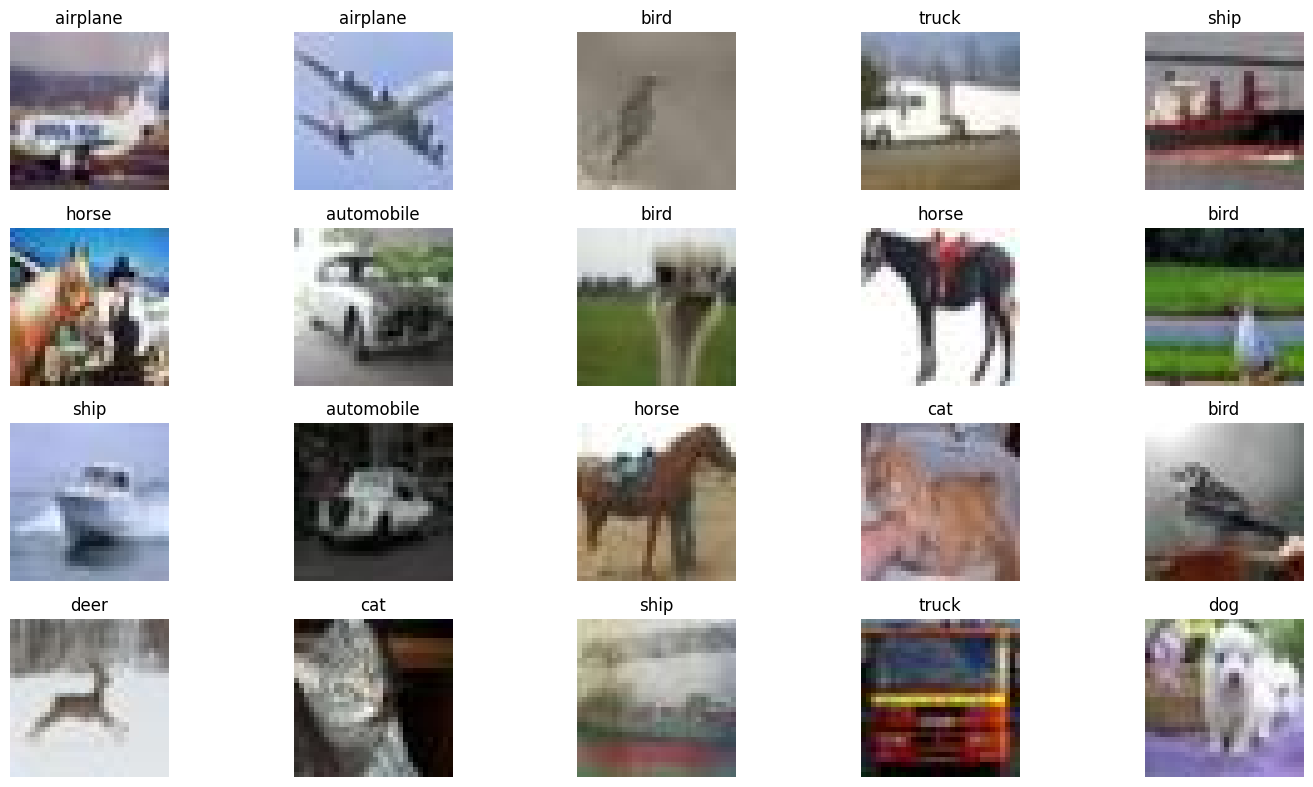

In [65]:
def display_random_images(df, dataset_name, num_images=20, rows=4, cols=5):
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
    
    random_indices = random.sample(range(len(df)), num_images)
    
    for ax, idx in zip(axes.ravel(), random_indices):
        img_path = df.iloc[idx]['img_path']
        img_label = df.iloc[idx]['label']
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        ax.imshow(img)
        ax.set_title(f'{img_label}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

display_random_images(df, 'train')

In [67]:
train, val, _, _ = train_test_split(df, df['label'], test_size=0.3, stratify=df['label'], random_state=CFG['SEED'])
# df : 분할 할 전체 데이터 프레임 
# train : 학습 데이터 프레임
# val : 검증 데이터 프레임
# stratify=df['label'] : 데이터 분할 시 클래스 비율을 유지하기 위해 stratify 매개변수를 사용
# 원본 데이터 프레임에서 레이블의 비율이 학습 데이터와 검증데이터에서도 동일하게 유지 
# random_state=CFG['SEED'] : 데이터 분할 시 랜덤성을 제어하기 위해 random_state 매개변수를 사용
display(train.head(5))
display(val.head(5))

,img_path,label
5187,./temp/train/dog/0110.jpg,dog
9768,./temp/train/dog/0323.jpg,dog
13270,./temp/train/truck/2970.jpg,truck
46660,./temp/train/automobile/2772.jpg,automobile
8411,./temp/train/dog/3267.jpg,dog


,img_path,label
8295,./temp/train/dog/2019.jpg,dog
41694,./temp/train/deer/0831.jpg,deer
43480,./temp/train/deer/3729.jpg,deer
18924,./temp/train/bird/2726.jpg,bird
21691,./temp/train/airplane/2954.jpg,airplane


In [68]:
# label encoding 
le = preprocessing.LabelEncoder()
train['label'] = le.fit_transform(train['label'])
#fit_transform() 메서드는 레이블 인코딩을 수행하면서 동시에 학습 데이터에 맞게 인코더를 학습시킵니다.
val['label'] = le.transform(val['label'])

display(train.head(5))
display(val.head(5))

,img_path,label
5187,./temp/train/dog/0110.jpg,5
9768,./temp/train/dog/0323.jpg,5
13270,./temp/train/truck/2970.jpg,9
46660,./temp/train/automobile/2772.jpg,1
8411,./temp/train/dog/3267.jpg,5


,img_path,label
8295,./temp/train/dog/2019.jpg,5
41694,./temp/train/deer/0831.jpg,4
43480,./temp/train/deer/3729.jpg,4
18924,./temp/train/bird/2726.jpg,2
21691,./temp/train/airplane/2954.jpg,0


# __getitem__ method



In [69]:
class CustomDataset(Dataset):
    def __init__(self, img_path_list, label_list=None, transforms=None):
        self.img_path_list = img_path_list
        self.label_list = label_list
        self.transforms = transforms
        
    def __getitem__(self, index):
        img_path = self.img_path_list[index]
        image = cv2.imread(img_path) #using opencv 
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #OpenCV is read basically BGR type
        #convert RGB type from BGR 
        
        if self.transforms is not None:
            image = self.transforms(image=image)['image']
        
        if self.label_list is not None:
            label = self.label_list[index]
            return image, label
        else:
            return image
        
    def __len__(self):
        return len(self.img_path_list)

## 학습 데이터 증강 및 데이터 로더 설정 

- DataLoader를 사용하여 학습(train) 및 검증(validation) 데이터 셋을 로드하는 과정을 포함 


In [70]:
train_transform = A.Compose([
    A.Resize(CFG['IMG_SIZE'], CFG['IMG_SIZE']), #이미지를 지정된 크기로 조정 
    A.HorizontalFlip(p=0.5),   # 랜덤 수평 뒤집기 
    A.VerticalFlip(p=0.5),     # 랜덤 수직 뒤집기
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.5), # 랜덤 이동, 크기 조정 및 회전
    A.CenterCrop(height=CFG['IMG_SIZE'], width=CFG['IMG_SIZE'], p=0.5), # 랜덤 크기 조정 및 자르기
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, always_apply=False, p=1.0),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(CFG['IMG_SIZE'], CFG['IMG_SIZE']),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, always_apply=False, p=1.0),
    ToTensorV2()
])

train_dataset = CustomDataset(train['img_path'].values, train['label'].values, train_transform)
train_loader = DataLoader(train_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=False, num_workers=0)

val_dataset = CustomDataset(val['img_path'].values, val['label'].values, test_transform)
val_loader = DataLoader(val_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=False, num_workers=0)

/Users/donghun2/workspace/machine_learning/dacon/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/ct/csn7gw6j4lzg64vvct28bvj00000gn/T/ipykernel_8358/2432386799.py:7: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, always_apply=False, p=1.0),
/var/folders/ct/csn7gw6j4lzg64vvct28bvj00000gn/T/ipykernel_8358/2432386799.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0, always_apply=False, p=1.0),


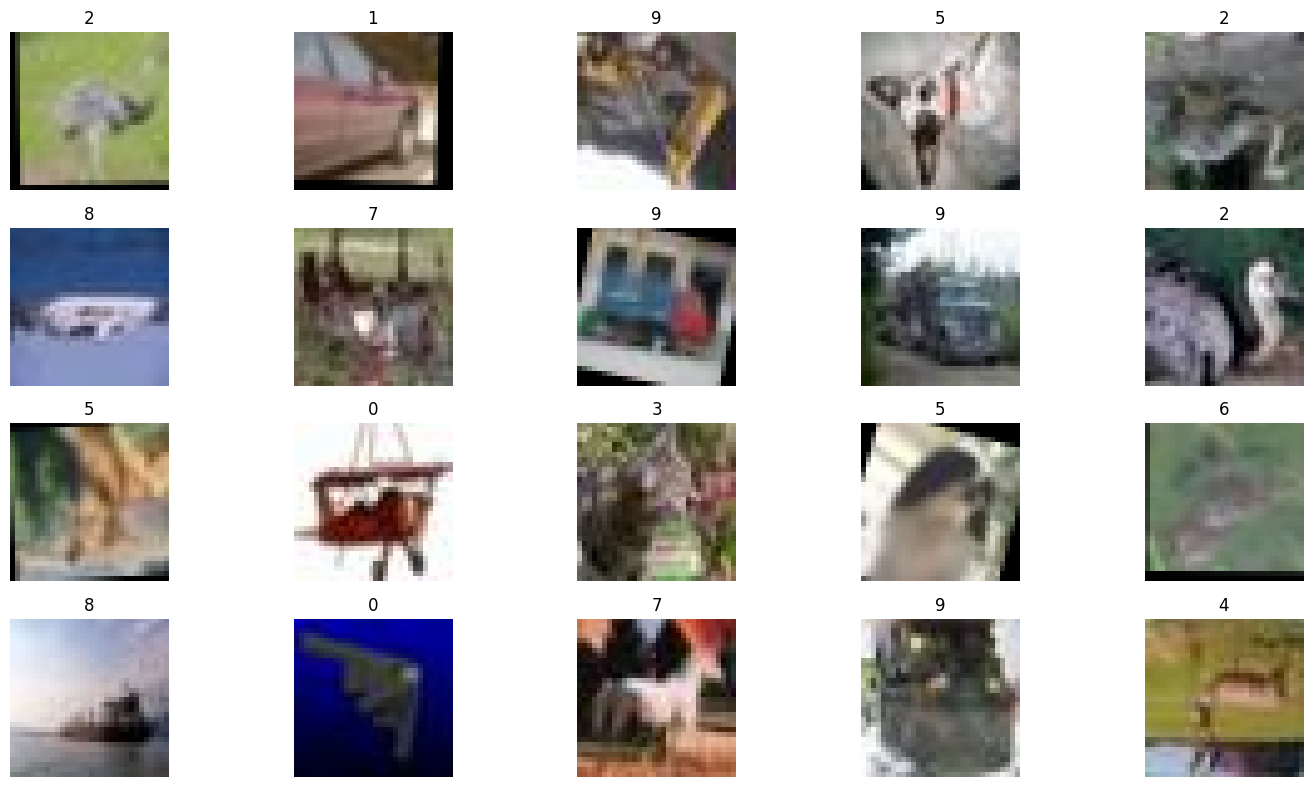

In [71]:
# 데이터 증강 적용 후 학습 데이터 셋 시각화 
def display_random_images_from_dataset(dataset, dataset_name, num_images=20, rows=4, cols=5):

    fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
    
    random_indices = random.sample(range(len(dataset)), num_images)
    
    for ax, idx in zip(axes.ravel(), random_indices):
        image, label = dataset[idx]
        image = image.permute(1, 2, 0).cpu().numpy()  # 채널 순서를 바꾸고 numpy 배열로 변환
        image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # 정규화 해제
        image = (image * 255).astype(np.uint8)  # 픽셀 값을 0-255 범위로 변환
        
        ax.imshow(image)
        ax.set_title(f'{label}')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

display_random_images_from_dataset(train_dataset, 'Train')

## 이미지 시각화 코드 설명 

이 코드는 `train_dataset`에서 랜덤으로 이미지 몇 장을 꺼내서, 데이터 증강이 적용된 결과를 화면에 보여주는 함수입니다.

핵심 흐름은 이렇습니다.

```text
데이터셋에서 랜덤 인덱스 선택
-> 이미지와 라벨 꺼냄
-> PyTorch Tensor 이미지를 matplotlib이 볼 수 있는 형태로 변환
-> Normalize 했던 값을 다시 원래 이미지 색상으로 되돌림
-> 화면에 출력
```

함수 정의부터 보면:

```python
def display_random_images_from_dataset(dataset, dataset_name, num_images=20, rows=4, cols=5):
```

`dataset`은 `train_dataset` 같은 PyTorch Dataset입니다. `num_images=20`은 총 20장을 보여주겠다는 뜻이고, `rows=4`, `cols=5`는 `4 x 5` 형태로 보여주겠다는 뜻입니다.

```python
fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
```

이미지를 그릴 공간을 만듭니다. `4 x 5`니까 총 20개의 작은 그래프 칸이 생깁니다.

```python
random_indices = random.sample(range(len(dataset)), num_images)
```

데이터셋 전체 인덱스 중에서 랜덤으로 20개를 뽑습니다. 예를 들어 데이터셋이 50000개면 그중 20개 번호를 무작위로 고릅니다.

```python
for ax, idx in zip(axes.ravel(), random_indices):
```

`axes`는 2차원 배열 형태입니다. `axes.ravel()`은 이걸 1차원으로 펴서 subplot 하나씩 접근하게 해줍니다.

```python
image, label = dataset[idx]
```

데이터셋에서 이미지와 라벨을 꺼냅니다. 여기서 중요한 점은 `dataset[idx]`를 호출하면 transform이 적용된 이미지가 나옵니다. 즉 Resize, Crop, Flip, Normalize 같은 처리가 반영된 상태입니다.

```python
image = image.permute(1, 2, 0).cpu().numpy()
```

PyTorch 이미지 텐서는 보통 이런 형태입니다.

```text
C x H x W
채널 x 높이 x 너비
```

예를 들어 컬러 이미지는:

```text
3 x 224 x 224
```

그런데 `matplotlib.pyplot.imshow()`는 이런 형태를 기대합니다.

```text
H x W x C
높이 x 너비 x 채널
```

그래서 `permute(1, 2, 0)`로 차원 순서를 바꿉니다.

```text
3 x 224 x 224 -> 224 x 224 x 3
```

`cpu()`는 텐서가 GPU에 있을 경우 CPU로 옮기는 것이고, `numpy()`는 NumPy 배열로 바꾸는 것입니다. `matplotlib`은 PyTorch Tensor보다 NumPy 배열을 다루기 편합니다.

```python
image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
```

이 부분은 **정규화 해제**입니다.

보통 이미지 학습 전에 이렇게 Normalize를 합니다.

```python
Normalize(mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225])
```

Normalize 공식은:

```text
x_normalized = (x - mean) / std
```

그걸 다시 원래 값으로 되돌리려면 반대로 계산합니다.

```text
x_original = x_normalized * std + mean
```

그래서 코드가 이렇게 되어 있습니다.

```python
image = image * std + mean
```

```python
image = (image * 255).astype(np.uint8)
```

정규화 해제 후 이미지는 보통 `0~1` 범위입니다. 화면에 일반 이미지처럼 보여주기 위해 `255`를 곱해서 `0~255` 범위로 바꿉니다. 그리고 이미지 픽셀 타입인 `uint8`로 변환합니다.

```python
ax.imshow(image)
```

이미지를 해당 subplot에 출력합니다.

```python
ax.set_title(f'{label}')
```

이미지 위에 라벨을 제목으로 표시합니다.

```python
ax.axis('off')
```

x축, y축 눈금을 숨깁니다.

마지막 호출:

```python
display_random_images_from_dataset(train_dataset, 'Train')
```

`train_dataset`에서 랜덤 이미지 20장을 뽑아서 보여줍니다.

다만 `dataset_name` 인자는 현재 함수 안에서 사용되지 않습니다. 제목으로 쓰고 싶으면 이런 줄을 추가할 수 있습니다.

```python
fig.suptitle(dataset_name)
```

정리하면 이 함수는 학습용 데이터셋에 적용된 augmentation 결과가 제대로 나오는지 눈으로 확인하는 디버깅용 시각화 함수입니다.

In [72]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        #입력 채널은 3(RGB image), kernel size 3x3, padding = 1
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        #max pooling layer 2x2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.conv6 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv7 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        #adaptive Average Pooling layer output 1x1
        self.flatten = nn.Flatten() # flatten working 
        ## fully Connected Layer = fc 
        self.fc1 = nn.Linear(512, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.dropout = nn.Dropout(0.7)
        #drop out: 과적합을 방지하기 위해 일부 뉴런을 무작위로 0으로 설정 
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = nn.ReLU()(x)
        x = self.conv2(x)
        x = nn.ReLU()(x)
        x = self.pool1(x)

        x = self.conv3(x)
        x = nn.ReLU()(x)
        x = self.conv4(x)
        x = nn.ReLU()(x)
        x = self.pool2(x)

        x = self.conv5(x)
        x = nn.ReLU()(x)
        x = self.conv6(x)
        x = nn.ReLU()(x)
        x = self.pool3(x)

        x = self.conv7(x)
        x = nn.ReLU()(x)
        x = self.pool4(x)

        x = self.adaptive_pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.fc2(x)
        x = nn.ReLU()(x)
        x = self.dropout(x)
        logits = self.fc3(x)

        return logits

In [73]:
def train(model, optimizer, train_loader, val_loader, scheduler, device):
    model.to(device)
    criterion = nn.CrossEntropyLoss().to(device)
    
    best_score = 0
    best_model = None
    train_losses = []
    valid_losses = []
    train_acc = []
    valid_acc = []
    
    for epoch in range(1, CFG['EPOCHS'] + 1):
        model.train()
        epoch_train_loss = []
        correct_train = 0
        total_train = 0
        for imgs, labels in tqdm(iter(train_loader)):
            imgs = imgs.float().to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            output = model(imgs)
            loss = criterion(output, labels)
            
            loss.backward()
            optimizer.step()
            
            epoch_train_loss.append(loss.item())
            _, predicted = torch.max(output.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        train_losses.append(np.mean(epoch_train_loss))
        train_acc.append(100 * correct_train / total_train)
        
        _val_loss, _val_score, _val_acc = validation(model, criterion, val_loader, device)
        valid_losses.append(_val_loss)
        valid_acc.append(_val_acc)
        
        print(f'Epoch [{epoch}], Train Loss : [{train_losses[-1]:.5f}] Val Loss : [{_val_loss:.5f}] Val Accuracy : [{_val_acc:.5f}] Val Weighted F1 Score : [{_val_score:.5f}]')
       
        if scheduler is not None:
            scheduler.step(_val_score)
            
        if best_score < _val_score:
            best_score = _val_score
            best_model = model
    
    return best_model, train_losses, valid_losses, train_acc, valid_acc

# 검증 함수 정의
def validation(model, criterion, val_loader, device):
    model.eval()
    val_loss = []
    preds, true_labels = [], []
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for imgs, labels in tqdm(iter(val_loader)):
            imgs = imgs.float().to(device)
            labels = labels.to(device)
            
            pred = model(imgs)
            
            loss = criterion(pred, labels)
            
            preds += pred.argmax(1).detach().cpu().numpy().tolist()
            true_labels += labels.detach().cpu().numpy().tolist()
            
            val_loss.append(loss.item())
            _, predicted = torch.max(pred.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        
        _val_loss = np.mean(val_loss)
        _val_score = f1_score(true_labels, preds, average='weighted')
        _val_acc = 100 * correct_val / total_val
    
    return _val_loss, _val_score, _val_acc

train()
1. model.train()으로 학습 모드
2. train_loader에서 batch 꺼냄
3. model(imgs)로 예측
4. loss 계산
5. loss.backward()로 gradient 계산
6. optimizer.step()으로 모델 업데이트
7. validation()으로 검증 성능 확인
8. 가장 좋은 모델 저장

validation()
1. model.eval()로 평가 모드
2. torch.no_grad()로 gradient 계산 끔
3. val_loader에서 batch 꺼냄
4. 예측만 수행
5. loss, accuracy, weighted F1 계산

In [74]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using {device} device')

model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=CFG["LEARNING_RATE"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, threshold_mode='abs', min_lr=1e-8)

# 학습률 스케쥴러 정의 
# ReduceLROnPlateau 스케쥴러는 검증 성능이 향상되지 않을 때 학습을 조정 
# mode = 'max' 성능 향상을 최대화 하려고 합니다. 
# factor = 0.5 학습률을 0.5배로 줄입니다. 
# patience=2, 성능 향상이 없을 떄 몇번의 에포크를 기다리는지 설명 
# threshold_mode='abs' 절대값 기준으로 성능을 비교 
# min_lr=le-8 학습률의 하한을 설정 
# verbose=True: 학습률이 줄어들 때 메시지를 출력 

Using cpu device


100%|██████████| 469/469 [00:53<00:00,  8.82it/s]


Epoch [1], Train Loss : [1.99561] Val Loss : [1.79980] Val Accuracy : [29.90000] Val Weighted F1 Score : [0.22698]


100%|██████████| 469/469 [00:52<00:00,  8.91it/s]

Epoch [2], Train Loss : [1.71051] Val Loss : [1.53117] Val Accuracy : [41.28000] Val Weighted F1 Score : [0.38583]


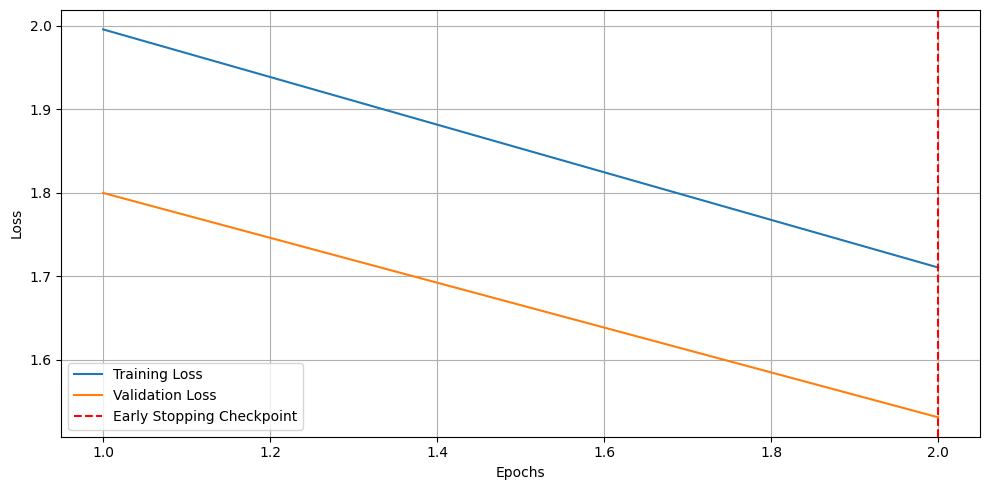

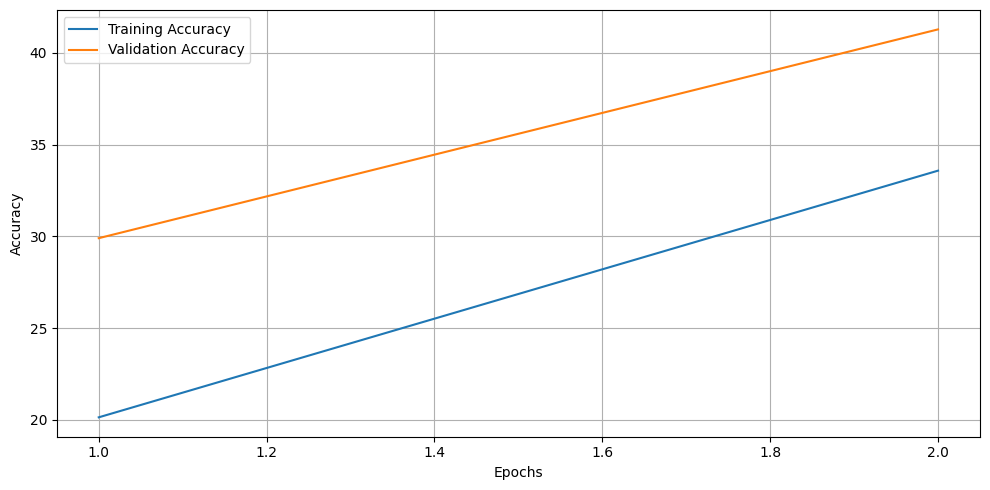

In [75]:
# 모델 학습
best_model, train_losses, valid_losses, train_acc, valid_acc = train(model, optimizer, train_loader, val_loader, scheduler, device)

# Loss 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label='Validation Loss')

# loss 최소값 지점에 마커 추가
minposs = valid_losses.index(min(valid_losses)) + 1 
plt.axvline(minposs, linestyle='--', color='r', label='Early Stopping Checkpoint')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 정확도 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy')
plt.plot(range(1, len(valid_acc) + 1), valid_acc, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
def sort_key(path):
    return int(path.split('/')[-1].split('.')[0])

test_img_list = glob.glob('./temp/test/*.jpg')
test_img_list = sorted(test_img_list, key=sort_key)

print(test_img_list[:10])

['./temp/test/0000.jpg', './temp/test/0001.jpg', './temp/test/0002.jpg', './temp/test/0003.jpg', './temp/test/0004.jpg', './temp/test/0005.jpg', './temp/test/0006.jpg', './temp/test/0007.jpg', './temp/test/0008.jpg', './temp/test/0009.jpg']


In [80]:
test_dataset = CustomDataset(test_img_list, transforms=test_transform)
test_loader = DataLoader(test_dataset, batch_size=CFG['BATCH_SIZE'], shuffle=False, num_workers=0)

# 모델 예측 함수
def inference(model, test_loader, device):
    model.eval()
    preds = []
    with torch.no_grad():
        for imgs in tqdm(iter(test_loader)):
            imgs = imgs.float().to(device)
            
            pred = model(imgs)
            
            preds += pred.argmax(1).detach().cpu().numpy().tolist()
    
    preds = le.inverse_transform(preds)
    return preds

# 모델 예측
preds = inference(best_model, test_loader, device)
preds

100%|██████████| 313/313 [00:33<00:00,  9.47it/s]


array(['horse', 'bird', 'ship', ..., 'frog', 'truck', 'frog'],
      shape=(10000,), dtype=object)

In [81]:
submission = pd.read_csv('./temp/sample_submission.csv')

submission['target'] = preds
submission.to_csv('./temp/submission.csv', index=False)